In [ ]:

import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def read_frametimes(filename):
  times = []
  with open(filename) as file:
    for line in file:
        line.rstrip()
        chunks = line.split(" ")
        if(len(chunks) != 3 or chunks[0] != "Frametime" or chunks[2] != "us\n"):
          print(chunks)
          raise ValueError(line)
        times.append(int(chunks[1]))
  # print(filename, len(times))
  return np.array(times)

def print_stats(frametimes, name):
  print(f"Num. of Frametimes {name}:\t{len(frametimes)}")
  print(f"Average {name}:\t\t\t {np.average(frametimes)} µs")
  print(f"Average FPS {name}:\t\t {10**6 / np.average(frametimes)}")
  print(f"Max {name}:\t\t\t\t {np.max(frametimes)} µs")
  print(f"Min {name}:\t\t\t\t {np.min(frametimes)} µs")
  print(f"Total Time {name}:\t\t\t {np.sum(frametimes) / (10**6)} s")
  plt.plot(frametimes)

In [ ]:
import pandas as pd

In [ ]:
import sys
from pathlib import Path
if len(sys.argv) > 1 and sys.argv[1] != "-f":
  pr_id = sys.argv[1]
  print(sys.argv)
else:
  current_path = Path(".")
  pr_benchmark_list = list(current_path.rglob("PR-*.txt"))
  if not pr_benchmark_list:
    print("No PR detected")
    sys.exit(1)
  else:
    splits = pr_benchmark_list[0].name.split("-")
    pr_id = splits[1]
print(f"Detected PR #{pr_id}")


Detected PR #12275


In [ ]:
# Define column headers
headers = ['map', 'version', '#frames', 'FT avg. (µs)', 'FT min (µs)', 'FT max (µs)', 'AVG FPS', 'worst 0.01 FPS', 'worst 0.001 FPS']
client_list = [
    "master",
    f"PR-{pr_id}",
]
#client_list = ["19.4", "19.4.cleanup"]
map_list = ["Abyss", "KingsLeap", "Linear", "Mud", "Victory 2", "run_world_war_zero", "ctf1", "Springlobe4"]
#map_list = ["multieasy"]
df = pd.DataFrame(columns=headers)
for map in map_list:
    for client in client_list:
        name = f"{client}-benchmark-{map}.txt"
        frametimes = read_frametimes(name)
        if not len(frametimes):
            print(f"{name} is empty")
            continue
        assert len(frametimes) > 200
        frametimes = frametimes[200:]

        # print_stats(frametimes, f"{client}-{map}")
        # plt.show()
        frametimes_sorted = np.sort(frametimes)
        topN = int(len(frametimes_sorted) * 0.01)
        frametimes_001 = frametimes_sorted[-topN:]

        topN = int(len(frametimes_sorted) * 0.001)
        frametimes_0001 = frametimes_sorted[-topN:]

        df.loc[f"{client}-{map}"] = [map, client, len(frametimes), np.average(frametimes), np.min(frametimes), np.max(frametimes),
                                     1000000 / np.average(frametimes), 1000000 / np.average(frametimes_001), 1000000 / np.average(frametimes_0001)]
print(df.to_markdown())

|                             | map                | version   |   #frames |   FT avg. (µs) |   FT min (µs) |   FT max (µs) |   AVG FPS |   worst 0.01 FPS |   worst 0.001 FPS |
|:----------------------------|:-------------------|:----------|----------:|---------------:|--------------:|--------------:|----------:|-----------------:|------------------:|
| master-Abyss                | Abyss              | master    |     55061 |        490.35  |            94 |         50493 |   2039.36 |          881.717 |           488.013 |
| PR-12275-Abyss              | Abyss              | PR-12275  |     54960 |        487.911 |            92 |          1186 |   2049.56 |          960.796 |           929.128 |
| master-KingsLeap            | KingsLeap          | master    |    117161 |        250.61  |            94 |         54521 |   3990.27 |         2239.51  |           995.863 |
| PR-12275-KingsLeap          | KingsLeap          | PR-12275  |    125298 |        234.418 |            92 |      

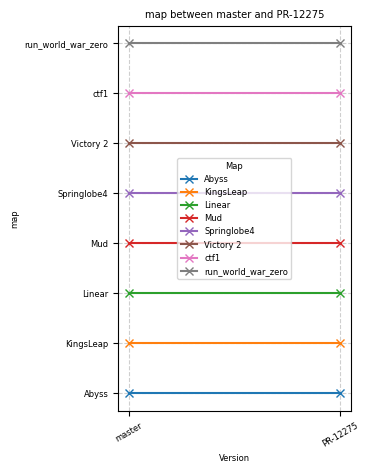

<Figure size 640x480 with 0 Axes>

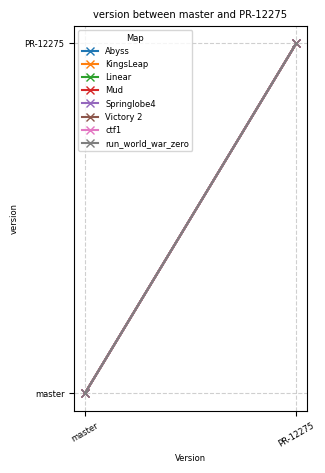

<Figure size 640x480 with 0 Axes>

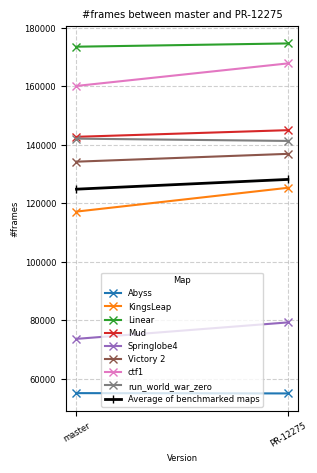

<Figure size 640x480 with 0 Axes>

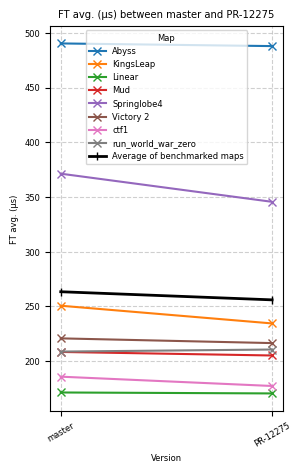

<Figure size 640x480 with 0 Axes>

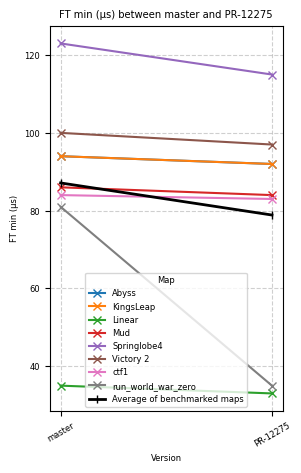

<Figure size 640x480 with 0 Axes>

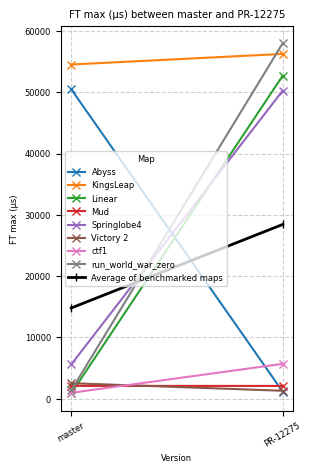

<Figure size 640x480 with 0 Axes>

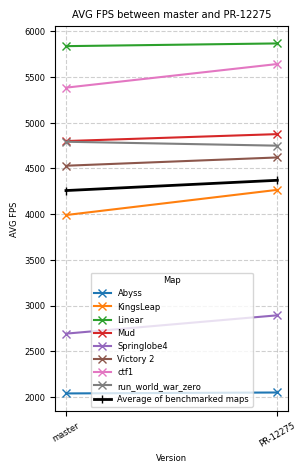

<Figure size 640x480 with 0 Axes>

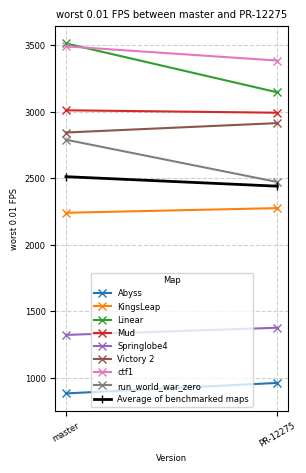

<Figure size 640x480 with 0 Axes>

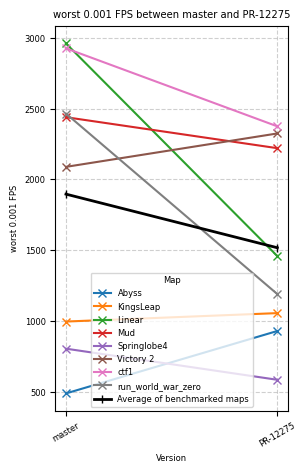

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.rcParams.update({'font.size': 6})
# Ensure versions are ordered correctly
df["version"] = pd.Categorical(df["version"], categories=df["version"].unique(), ordered=True)

for metric in headers:
  plt.figure(figsize=(3, 5))
  for map_name, map_df in df.groupby("map"):
    plt.plot(map_df["version"], map_df[metric], marker='x', label=map_name)

  # --- GLOBAL AVERAGE LINE ---
  # --- AVERAGE PER VERSION (line with dots) ---
  if metric != "map" and metric != "version":
    avg_df = (
      df.groupby("version", observed=True)[metric]
      .mean()
      .reset_index()
    )

    plt.plot(
      avg_df["version"],
      avg_df[metric],
      marker='|',           # dots
      linestyle='-',
      linewidth=2.0,
      color='black',
      label='Average of benchmarked maps'
    )
    # ------------------------------------------
  # --------------------------

  plt.xlabel("Version")
  plt.ylabel(metric)
  plt.title(f"{metric} between master and PR-{pr_id}")
  plt.legend(title="Map")
  plt.grid(True, linestyle="--", alpha=0.6)
  #plt.tight_layout()
  #plt.setp(plt.get_xticklabels(), rotation=30, horizontalalignment='right')
  plt.xticks(rotation=30)
  plt.show()
  plt.savefig(f"DDNet-benchmark-{metric.replace(' ', '_')}.png")